In [6]:
!pip show matplotlib seaborn scikit-learn tensorflow

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [9]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# IMPORTANT: Update this path to your zipped file in Google Drive
# Example: '/content/drive/MyDrive/my_folder/my_zipped_file.zip'
z_file_path = '/content/drive/MyDrive/tomato classifier project dataset.zip'

# Specify the destination directory to unzip the files
destination_path = './datasets/' # Unzip to a 'datasets' folder in the current Colab environment

# Create the destination directory if it doesn't exist
os.makedirs(destination_path, exist_ok=True)

# Unzip the file
try:
    with zipfile.ZipFile(z_file_path, 'r') as zip_ref:
        zip_ref.extractall(destination_path)
    print(f'Successfully unzipped {z_file_path} to {destination_path}')
except FileNotFoundError:
    print(f'Error: Zipped file not found at {z_file_path}')
except zipfile.BadZipFile:
    print(f'Error: The file at {z_file_path} is not a valid zip file.')
except Exception as e:
    print(f'An unexpected error occurred: {e}')

Mounted at /content/drive
Successfully unzipped /content/drive/MyDrive/tomato classifier project dataset.zip to ./datasets/


In [11]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
accuracy_score, precision_score, recall_score,
f1_score, classification_report, confusion_matrix
)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to : {SEED}')

TensorFlow version : 2.20.0
Random seed set to : 42


In [13]:
results_dir = "results/lab7/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

In [15]:
!nvidia-smi
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'\nGPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f'  - {gpu}')
else:
    print('\nNo GPU found — training will run on CPU (slower).')

Fri Jul 31 20:55:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
import os
import shutil
base_input = "../datasets/PlantVillage_Dataset"
base_output = "../datasets/PlantVillage_Dataset_Renamed/"
base_path = Path(base_output)
base_path

PosixPath('../datasets/PlantVillage_Dataset_Renamed')

In [27]:
import os
import shutil
import random

# User-defined splits and their ratios
TRAIN_RATIO = 0.7
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Ensure ratios sum to 1 (or close to it due to floating point)
if not (TRAIN_RATIO + VAL_RATIO + TEST_RATIO > 0.99 and TRAIN_RATIO + VAL_RATIO + TEST_RATIO < 1.01):
    raise ValueError("Train, Val, and Test ratios must sum to 1.")

# Corrected base_input path: Assuming 'tomato classifier project dataset' is the root folder
# containing the individual plant-disease categories (e.g., 'Tomato___healthy').
# The variable `destination_path` is available from a previous cell and holds './datasets/'
base_input = os.path.join(destination_path, 'tomato classifier project dataset')

# User requested to output to Google Drive
base_output = "/content/drive/MyDrive/PlantVillage_Dataset_Renamed/"

# Prepare output directories
output_train_dir = os.path.join(base_output, 'train')
os.makedirs(output_train_dir, exist_ok=True)
output_val_dir   = os.path.join(base_output, 'val')
os.makedirs(output_val_dir, exist_ok=True)
output_test_dir  = os.path.join(base_output, 'test')
os.makedirs(output_test_dir, exist_ok=True)

# List all disease categories in the base_input directory
disease_categories = [d for d in os.listdir(base_input) if os.path.isdir(os.path.join(base_input, d))]

print(f"Restructuring dataset from '{base_input}' to '{base_output}'...")

for class_name in disease_categories:
    src_class_dir = os.path.join(base_input, class_name)
    all_images = [f for f in os.listdir(src_class_dir) if os.path.isfile(os.path.join(src_class_dir, f))]
    random.shuffle(all_images) # Shuffle images before splitting

    num_images = len(all_images)
    num_train  = int(TRAIN_RATIO * num_images)
    num_val    = int(VAL_RATIO * num_images)
    # num_test = num_images - num_train - num_val # Remaining images go to test

    train_images = all_images[:num_train]
    val_images   = all_images[num_train : num_train + num_val]
    test_images  = all_images[num_train + num_val:]

    # Copy images to respective split directories
    for img_list, output_split_dir in zip(
        [train_images, val_images, test_images],
        [output_train_dir, output_val_dir, output_test_dir]
    ):
        dst_dir = os.path.join(output_split_dir, class_name)
        os.makedirs(dst_dir, exist_ok=True)
        for img_file in img_list:
            src_file = os.path.join(src_class_dir, img_file)
            shutil.copy(src_file, os.path.join(dst_dir, img_file))

print(f"Dataset restructuring complete. Output saved to: {base_output}")

Restructuring dataset from './datasets/tomato classifier project dataset' to '/content/drive/MyDrive/PlantVillage_Dataset_Renamed/'...
Dataset restructuring complete. Output saved to: /content/drive/MyDrive/PlantVillage_Dataset_Renamed/


In [28]:
BASE_DIR = Path(base_output)
train_dir      = BASE_DIR / 'train'
val_dir        = BASE_DIR / 'val'
test_dir       = BASE_DIR / 'test'

In [31]:
print('Verifying restructured dataset directories:')
for split_name, d in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
    target_dir = str(d) # Convert Path object to string for os.path functions
    print(f'{split_name:>5} directory: {target_dir}')
    if os.path.isdir(target_dir):
        exists = True
        count = 0
        for root, _, files in os.walk(target_dir):
            for file in files:
                # Count common image file extensions
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    count += 1
        print(f'         exists=True  images≈{count}')
    else:
        exists = False
        count = 0
        print(f'         exists=False (Directory not found or not accessible)')


Verifying restructured dataset directories:
train directory: /content/drive/MyDrive/PlantVillage_Dataset_Renamed/train
         exists=True  images≈179
  val directory: /content/drive/MyDrive/PlantVillage_Dataset_Renamed/val
         exists=True  images≈38
 test directory: /content/drive/MyDrive/PlantVillage_Dataset_Renamed/test
         exists=True  images≈40


In [35]:
IMAGE_HEIGHT = 128
IMAGE_WIDTH  = 128
BATCH_SIZE   = 64
EPOCHS = 50
LR = 1e-3   # Initial learning rate for the CNN from scratch

print(f'Image size  : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Max epochs  : {EPOCHS}')
print(f'Learning rate: {LR}')

Image size  : 128 x 128
Batch size  : 64
Max epochs  : 50
Learning rate: 0.001


In [38]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
train_dir,image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
batch_size=BATCH_SIZE,seed=SEED, shuffle=True,
)

Found 179 files belonging to 2 classes.


In [39]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)

Found 38 files belonging to 2 classes.


In [40]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
batch_size=BATCH_SIZE, seed=SEED,shuffle=False,
)

Found 40 files belonging to 2 classes.


In [42]:
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

Classes (2): ['Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']


In [44]:
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

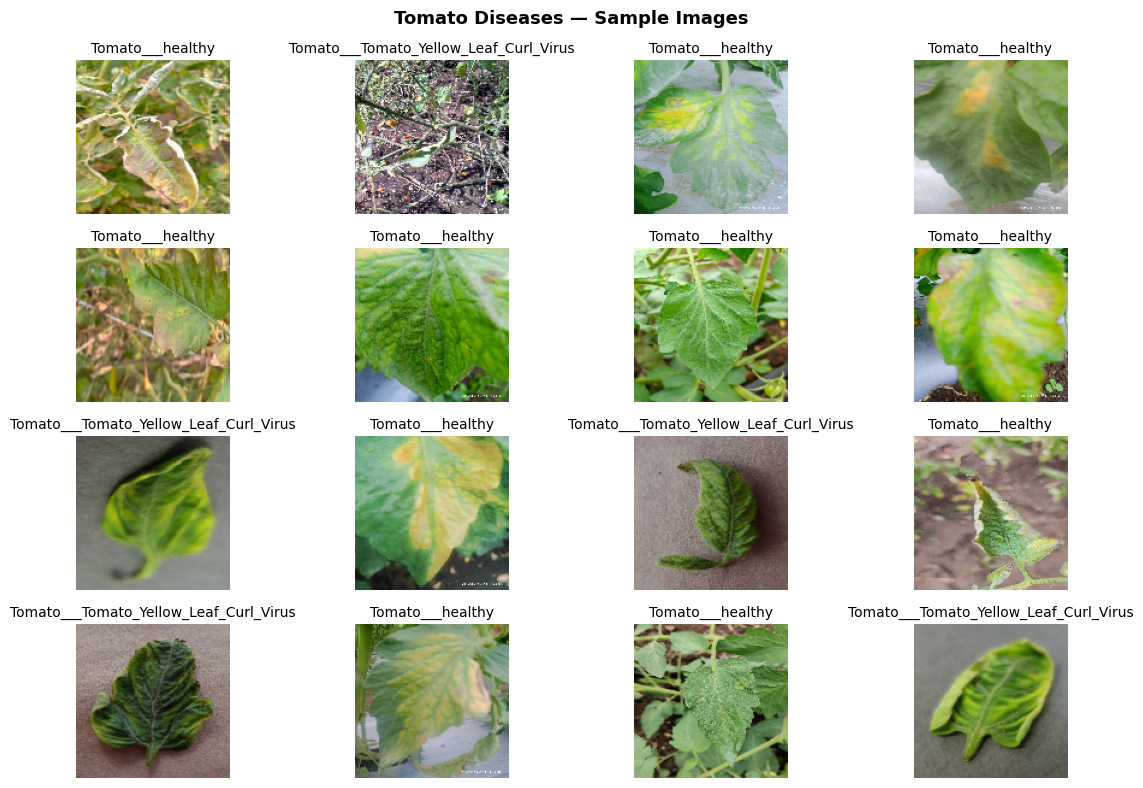

In [46]:
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(class_names[fixed_labels[i]], fontsize=10)
    plt.axis('off')
plt.suptitle('Tomato Diseases — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [47]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = (
train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE))
val_dataset = (val_dataset.cache().prefetch(buffer_size=AUTOTUNE))
test_dataset = (test_dataset.cache().prefetch(buffer_size=AUTOTUNE))
print('Pipeline optimised with cache + shuffle + prefetch.')

Pipeline optimised with cache + shuffle + prefetch.


In [48]:
data_augmentation = tf.keras.Sequential([
   tf.keras.layers.RandomFlip('horizontal'),
   tf.keras.layers.RandomRotation(0.2),
   tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

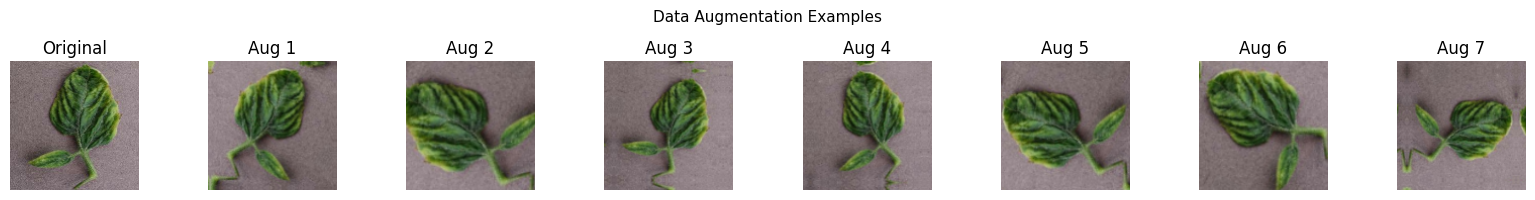

In [49]:
for images, _ in train_dataset.take(1):
   sample = images[0:1]  # shape (1, 224, 224, 3)
   break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 8):
   aug_img = data_augmentation(sample,
training=True)[0].numpy().astype('uint8')
   axes[i].imshow(aug_img)
   axes[i].set_title(f'Aug {i}')
   axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig('lab8_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()

In [51]:
os.makedirs('models', exist_ok=True)
def make_callbacks(name):
   """Return a fresh set of callbacks for each model."""
   return [
       tf.keras.callbacks.ModelCheckpoint(
           filepath=f'models/{name}_best.keras',
           monitor='val_accuracy', save_best_only=True,
       ),
       tf.keras.callbacks.EarlyStopping(
           monitor='val_loss', patience=8,
           restore_best_weights=True, verbose=1,
       ),
   ]

In [53]:

def plot_learning_curves(history, title='Learning Curves'):
   """Plot accuracy and loss curves side-by-side."""
   acc      = history.history['accuracy']
   val_acc  = history.history['val_accuracy']
   loss     = history.history['loss']
   val_loss = history.history['val_loss']
   epochs_range = range(len(acc))

   plt.figure(figsize=(14, 5))
   plt.subplot(1, 2, 1)
   plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
   plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2,
linestyle='--')
   plt.legend()
   plt.title(f'{title} — Accuracy')
   plt.xlabel('Epoch')
   plt.ylabel('Accuracy')
   plt.grid(alpha=0.3)

   plt.subplot(1, 2, 2)
   plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
   plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2,
linestyle='--')
   plt.legend()
   plt.title(f'{title} — Loss')
   plt.xlabel('Epoch')
   plt.ylabel('Loss')
   plt.grid(alpha=0.3)

   plt.tight_layout()
   plt.savefig(results_dir + f'lab8_{title.lower().replace(" ",
"_")}_curves.png', dpi=120, bbox_inches='tight')
   plt.show()

def evaluate_model(model, dataset, class_names, title='Model',
results_dir='./'):
   """Evaluate a multiclass classification model."""

   y_true, y_pred, y_prob = [], [], []
   for images, labels in dataset:
       probs = model.predict(images, verbose=0)

       # multiclass prediction (softmax -> argmax)
       preds = np.argmax(probs, axis=1)

       y_prob.append(probs)
       y_pred.append(preds)
       y_true.append(labels.numpy())
   y_true = np.concatenate(y_true)
   y_pred = np.concatenate(y_pred)
   y_prob = np.concatenate(y_prob)

   print(f"\n{title}")

   print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
   print(f'Precision : {precision_score(y_true, y_pred,
average="weighted"):.4f}')
   print(f'Recall    : {recall_score(y_true, y_pred,
average="weighted"):.4f}')
   print(f'F1-Score  : {f1_score(y_true, y_pred, average="weighted"):.4f}')

   print("\nClassification Report:")
   print(classification_report(y_true, y_pred, target_names=class_names,
digits=4))

   # Confusion Matrix
   cm = confusion_matrix(y_true, y_pred)
   plt.figure(figsize=(15, 12))
   sns.heatmap(
       cm, cmap='Blues', cbar=False, annot=True, fmt='',
       xticklabels=class_names, yticklabels=class_names,
       annot_kws={'fontsize': 9, 'fontweight': 'bold'}
   )
   plt.title(f'{title} — Confusion Matrix')
   plt.xlabel('Predicted')
   plt.ylabel('True')
   plt.xticks(rotation=45, ha='right')
   plt.yticks(rotation=0)
   plt.tight_layout()
   plt.savefig(
       results_dir + f'lab8_{title.lower().replace(" ",
"_")}_confusion.png',
       dpi=120,
       bbox_inches='tight'
   )
   plt.show()

   return accuracy_score(y_true, y_pred)
print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


In [54]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
OUTPUTS = num_classes
def build_custom_cnn(input_shape, augmentation):
   """
   A three-block CNN built entirely from scratch.
   Filters double each block (32 >> 64 >> 128) following a standard design
pattern.
   Augmentation is embedded inside the model so it runs automatically during
training.
   """
   inputs = tf.keras.Input(shape=input_shape)

   # Augmentation (active only during training)
   x = augmentation(inputs)

   # Normalise pixel values from [0, 255] to [0, 1]
   x = tf.keras.layers.Rescaling(1.0 / 255)(x)

   # Block 1: 32 filters
   x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.MaxPooling2D()(x)
   x = tf.keras.layers.Dropout(0.25)(x)

   # Block 2: 64 filters
   x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.MaxPooling2D()(x)
   x = tf.keras.layers.Dropout(0.25)(x)

   # Block 3: 128 filters
   x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.MaxPooling2D()(x)
   x = tf.keras.layers.Dropout(0.25)(x)

   # Classification Head
   x = tf.keras.layers.GlobalAveragePooling2D()(x)
   x = tf.keras.layers.Dense(256, activation='relu')(x)
   x = tf.keras.layers.Dropout(0.5)(x)

   # Binary output: sigmoid → probability of class 1 (dogs)
   outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)

   return tf.keras.Model(inputs, outputs, name='custom_cnn')

cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 322,338 (1.23 MB)

 Trainable params: 321,442 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [57]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

cnn_history = cnn_model.fit(
    train_dataset, validation_data=val_dataset,epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn'), verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7486 - loss: 0.5892 - val_accuracy: 0.6053 - val_loss: 0.6645
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.9106 - loss: 0.2220 - val_accuracy: 0.6053 - val_loss: 0.6491
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.9553 - loss: 0.0977 - val_accuracy: 0.6053 - val_loss: 0.6532
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - accuracy: 0.9553 - loss: 0.1239 - val_accuracy: 0.6053 - val_loss: 0.6324
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.9777 - loss: 0.0552 - val_accuracy: 0.6053 - val_loss: 0.6273
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 0.9721 - loss: 0.0773 - val_accuracy: 0.6053 - val_loss: 0.6163
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.9665 - loss: 0.0749 - val_accuracy: 0.6053 - val_loss: 0.6034
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.9832 - loss: 0.0423 - val_accuracy: 0.6053 - val_loss: 0

In [58]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN  ->  val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

Custom CNN  ->  val_loss: 0.5566
val_accuracy: 0.7632


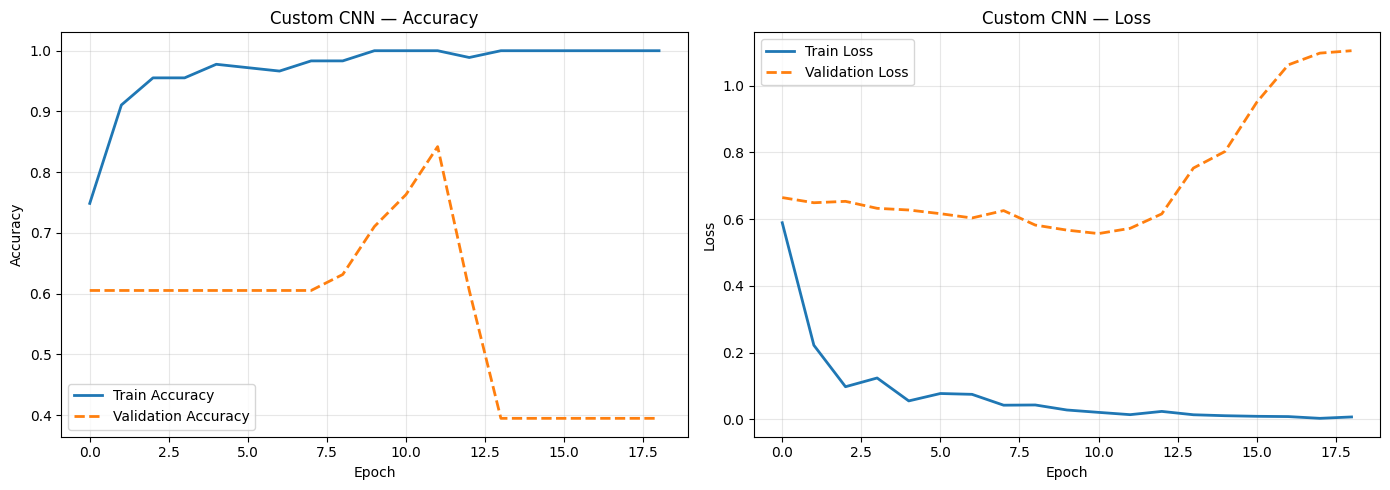

In [59]:
plot_learning_curves(cnn_history, 'Custom CNN')


Custom CNN
Accuracy  : 0.6750
Precision : 0.6979
Recall    : 0.6750
F1-Score  : 0.6102

Classification Report:
                                        precision    recall  f1-score   support

Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.7500    0.2000    0.3158        15
                      Tomato___healthy     0.6667    0.9600    0.7869        25

                              accuracy                         0.6750        40
                             macro avg     0.7083    0.5800    0.5513        40
                          weighted avg     0.6979    0.6750    0.6102        40



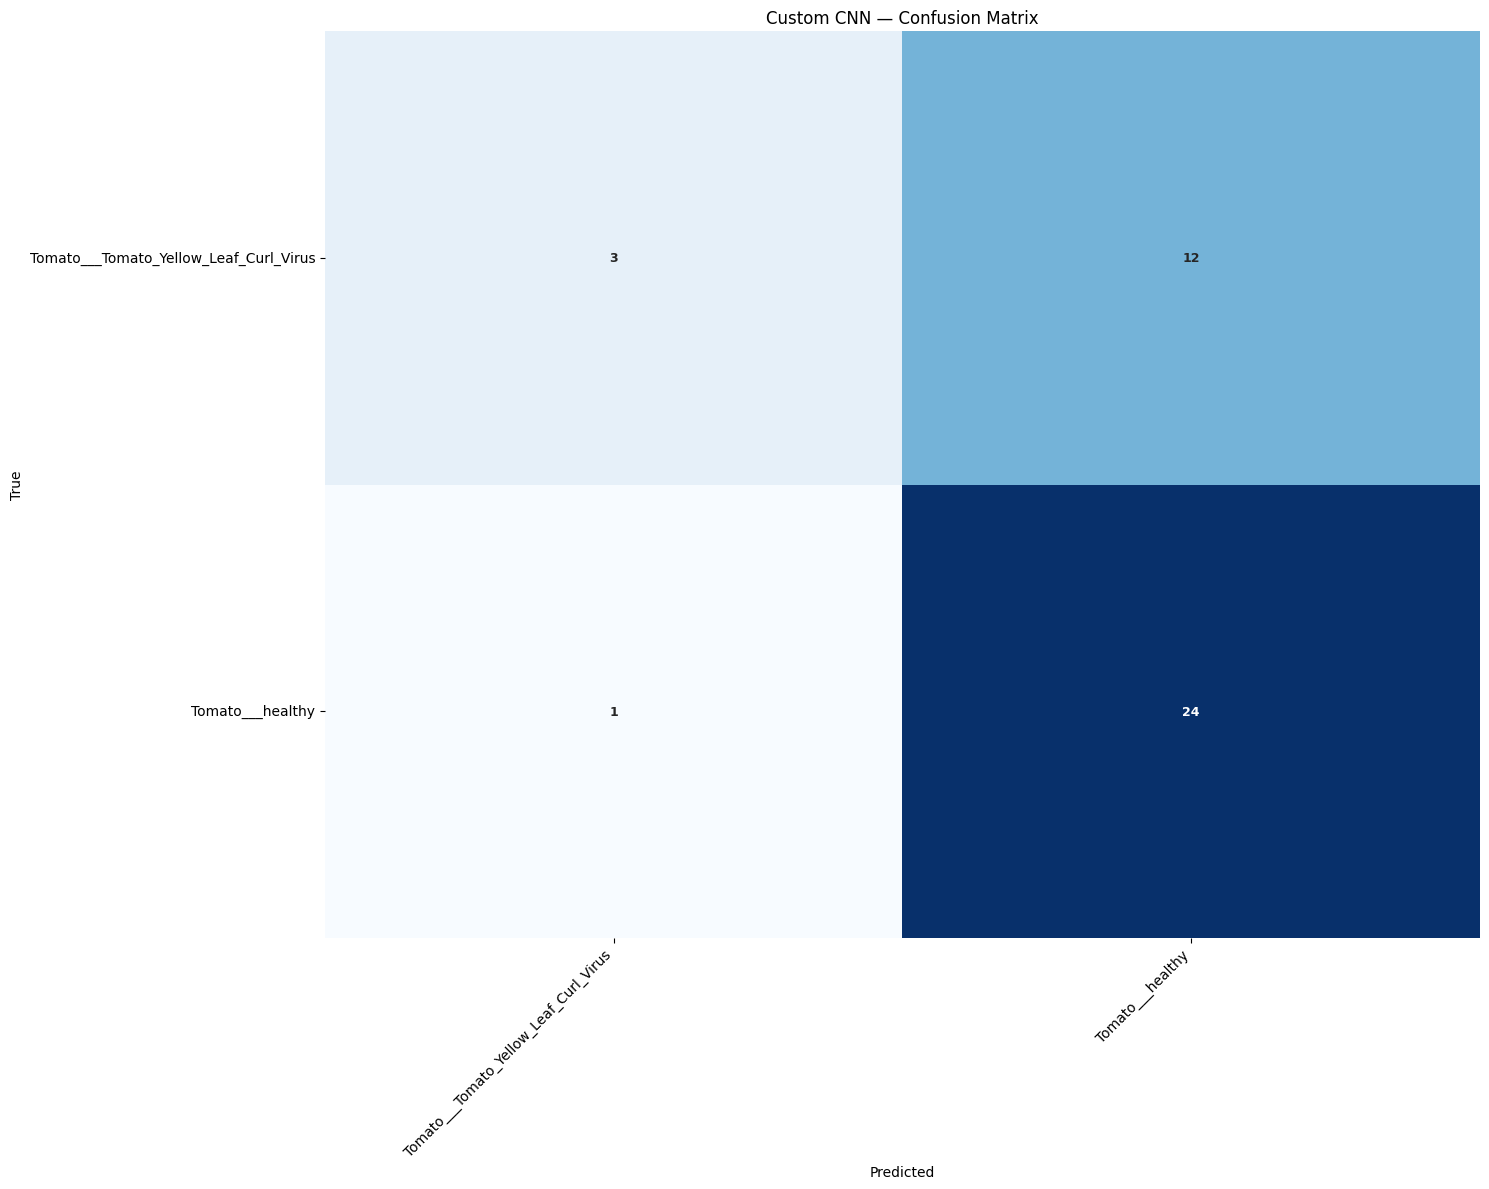

In [60]:
cnn_test_acc = evaluate_model(cnn_model, test_dataset,
class_names, 'Custom CNN')

In [61]:
def build_transfer_model(input_shape, augmentation,
backbone='mobilenetv3small'):
   """
   Feature extraction model:
     1. Augment input (training only)
     2. Preprocess for MobileNetV3 (scales to [-1, 1])
     3. Frozen MobileNetV3Small backbone (no top)
     4. GlobalAveragePooling2D
     5. Dense classification head
   """
   if backbone == 'mobilenetv3small':
       base_model = tf.keras.applications.MobileNetV3Small(
           weights='imagenet',
           input_shape=input_shape,
           include_top=False,
       )
       preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
       model_name    = 'mobilenetv3small_transfer'

   else:

       # Fallback: MobileNetV2
       base_model = tf.keras.applications.MobileNetV2(
           weights='imagenet',
           input_shape=input_shape,
           include_top=False,
       )
       preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
       model_name    = 'mobilenetv2_transfer'

   # Freeze all base layers for feature extraction (no training)
   base_model.trainable = False
   print(f'Base model     : {base_model.name}')
   print(f'Trainable layers: {sum(1 for l in base_model.layers if
l.trainable)} / {len(base_model.layers)}')

   # Build the model graph
   inputs = tf.keras.Input(shape=input_shape)
   x = augmentation(inputs)
   x = preprocess_fn(x)  # scale pixels to [-1, 1]
   x = base_model(x, training=False)    # frozen inference mode
   x = tf.keras.layers.GlobalAveragePooling2D()(x)
   x = tf.keras.layers.Dense(256, activation='relu')(x)
   x = tf.keras.layers.Dropout(0.2)(x)
   outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)

   return tf.keras.Model(inputs, outputs, name=model_name), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation,
backbone='mobilenetv3small')
tl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model     : MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,346 (4.15 MB)

 Trainable params: 148,226 (579.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [62]:
TL_LR = 1e-4   # Lower LR for transfer learning head
tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=TL_LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
tl_history = tl_model.fit(
train_dataset,
validation_data=val_dataset,
epochs=EPOCHS,
callbacks=make_callbacks('tl_feature_extraction'),
verbose=1,
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4693 - loss: 0.8339 - val_accuracy: 0.5789 - val_loss: 0.7026
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.5251 - loss: 0.7308 - val_accuracy: 0.6842 - val_loss: 0.5837
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 390ms/step - accuracy: 0.6704 - loss: 0.6005 - val_accuracy: 0.7895 - val_loss: 0.4916
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 413ms/step - accuracy: 0.7989 - loss: 0.4618 - val_accuracy: 0.8947 - val_loss: 0.4225
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.8045 - loss: 0.4365 - val_accuracy: 0.8947 - val_loss: 0.3709
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8827 - loss: 0.3515 - val_accuracy: 0.8947 - val_loss: 0.3314
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 435ms/step - accuracy: 0.8827 - loss: 0.3285 - val_accuracy: 0.9211 - val_loss: 0.3023
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9274 - loss: 0.2636 - val_accuracy: 0.9211 - val_loss: 0.2

MobileNetV3 TL  ->  val_loss: 0.0970
MobileNetV3 TL  ->  val_accuracy: 0.9474


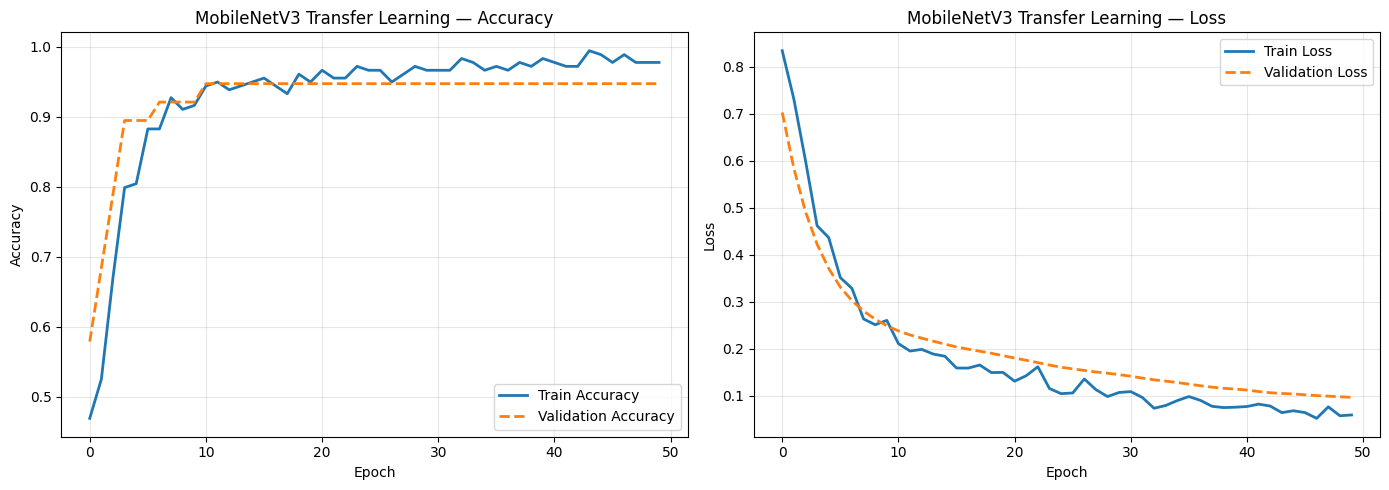

In [63]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV3 TL  ->  val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL  ->  val_accuracy: {tl_val_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')


MobileNetV3 Transfer
Accuracy  : 0.9750
Precision : 0.9766
Recall    : 0.9750
F1-Score  : 0.9751

Classification Report:
                                        precision    recall  f1-score   support

Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.9375    1.0000    0.9677        15
                      Tomato___healthy     1.0000    0.9600    0.9796        25

                              accuracy                         0.9750        40
                             macro avg     0.9688    0.9800    0.9737        40
                          weighted avg     0.9766    0.9750    0.9751        40



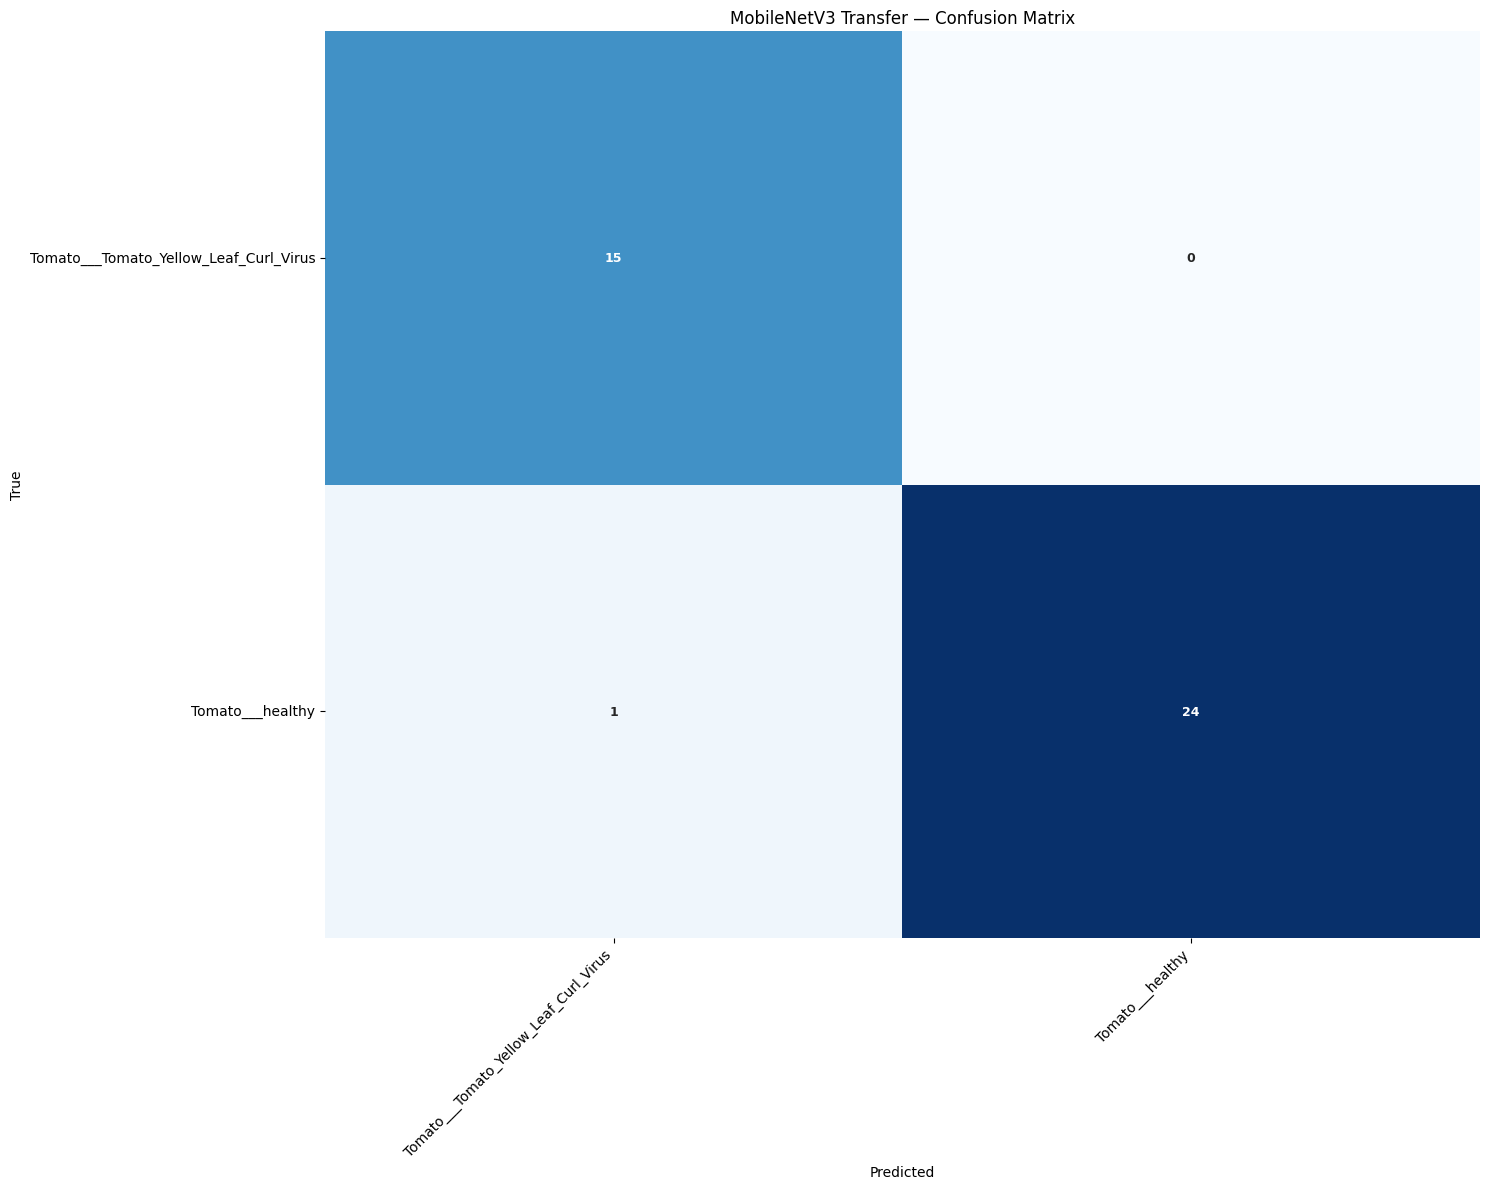

In [64]:
tl_test_acc = evaluate_model(tl_model, test_dataset, class_names,
'MobileNetV3 Transfer')

In [67]:
# Unfreeze the top 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')

Trainable base layers after unfreezing: 30 / 157


In [68]:
FINETUNE_LR = TL_LR / 10
tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)

In [69]:
ft_history = tl_model.fit(
train_dataset, validation_data=val_dataset, epochs=20,
callbacks=make_callbacks('tl_finetuned'), verbose=2,
)

Epoch 1/20
3/3 - 14s - 5s/step - accuracy: 0.9385 - loss: 0.1525 - val_accuracy: 0.9474 - val_loss: 0.0946
Epoch 2/20
3/3 - 3s - 922ms/step - accuracy: 0.9553 - loss: 0.1485 - val_accuracy: 0.9474 - val_loss: 0.0924
Epoch 3/20
3/3 - 0s - 103ms/step - accuracy: 0.9609 - loss: 0.0992 - val_accuracy: 0.9474 - val_loss: 0.0904
Epoch 4/20
3/3 - 1s - 236ms/step - accuracy: 0.9665 - loss: 0.1301 - val_accuracy: 0.9737 - val_loss: 0.0886
Epoch 5/20
3/3 - 0s - 66ms/step - accuracy: 0.9777 - loss: 0.1056 - val_accuracy: 0.9737 - val_loss: 0.0870
Epoch 6/20
3/3 - 0s - 68ms/step - accuracy: 0.9609 - loss: 0.1117 - val_accuracy: 0.9737 - val_loss: 0.0854
Epoch 7/20
3/3 - 0s - 66ms/step - accuracy: 0.9441 - loss: 0.1518 - val_accuracy: 0.9737 - val_loss: 0.0839
Epoch 8/20
3/3 - 0s - 71ms/step - accuracy: 0.9665 - loss: 0.1138 - val_accuracy: 0.9737 - val_loss: 0.0825
Epoch 9/20
3/3 - 0s - 68ms/step - accuracy: 0.9665 - loss: 0.1097 - val_accuracy: 0.9737 - val_loss: 0.0812
Epoch 10/20
3/3 - 0s - 68m

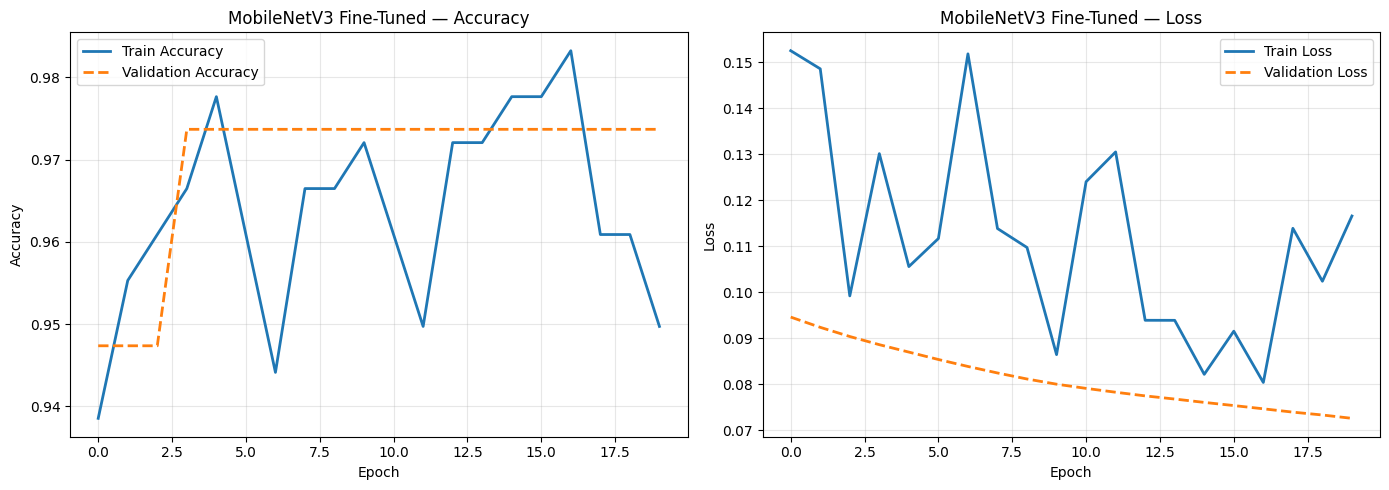

In [70]:
plot_learning_curves(ft_history, 'MobileNetV3 Fine-Tuned')


MobileNetV3 Fine-Tuned
Accuracy  : 0.9500
Precision : 0.9559
Recall    : 0.9500
F1-Score  : 0.9505

Classification Report:
                                        precision    recall  f1-score   support

Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.8824    1.0000    0.9375        15
                      Tomato___healthy     1.0000    0.9200    0.9583        25

                              accuracy                         0.9500        40
                             macro avg     0.9412    0.9600    0.9479        40
                          weighted avg     0.9559    0.9500    0.9505        40



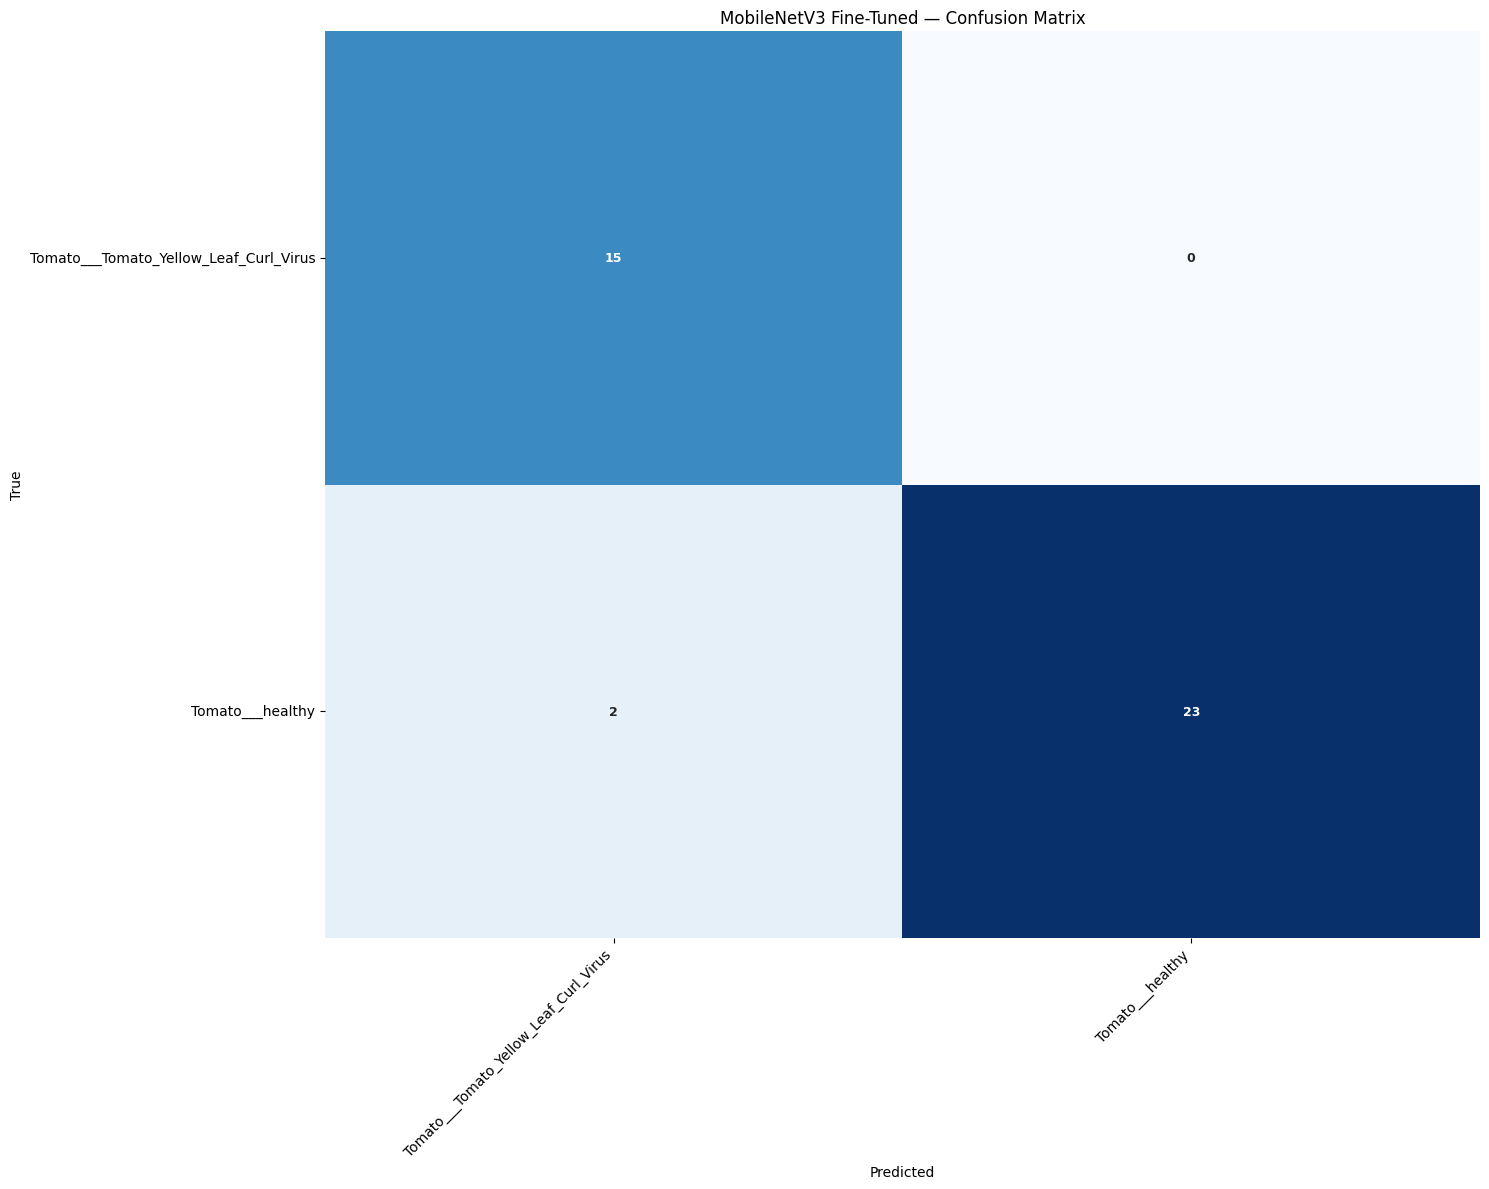

In [71]:
ft_test_acc = evaluate_model(tl_model,
test_dataset, class_names, 'MobileNetV3 Fine-Tuned')

In [73]:
results = {
'Custom CNN': {'acc': cnn_test_acc,  'params': cnn_model.count_params()},
'MobileNetV3 (TL)':
{'acc': tl_test_acc,   'params':
tl_model.count_params()}, 'MobileNetV3 (FT)': {'acc': ft_test_acc,
'params': tl_model.count_params()},}
print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')
print('-' * 55)
for name, vals in results.items():
    print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')

Model                       Test Acc         Params
-------------------------------------------------------
Custom CNN                    0.6750        322,338
MobileNetV3 (TL)              0.9750      1,087,346
MobileNetV3 (FT)              0.9500      1,087,346


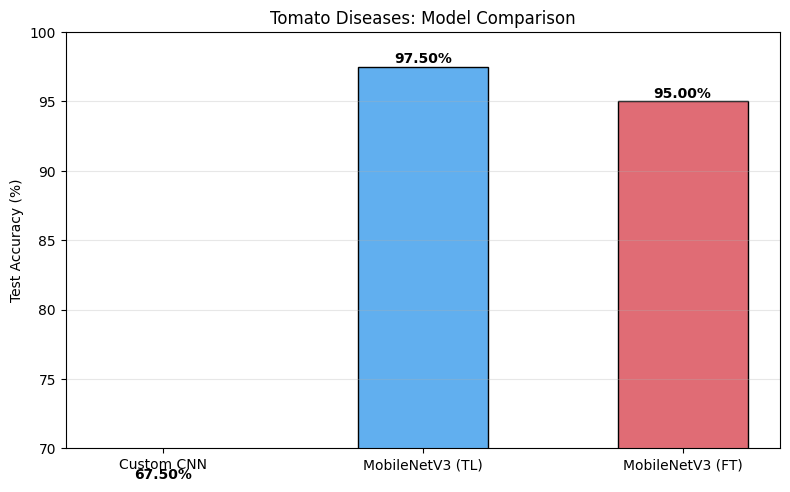

In [75]:
labels = list(results.keys())
accs   = [v['acc'] * 100 for v in results.values()]
colors = ['#e06c75', '#61afef']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)
ax.set_ylim(70, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Tomato Diseases: Model Comparison')
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
   ax.text(bar.get_x() + bar.get_width() / 2,
           bar.get_height() + 0.3,
           f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

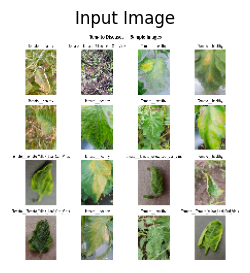


Predictions for: ./lab8_samples.png
----------------------------------------
Custom CNN               : Tomato___Tomato_Yellow_Leaf_Curl_Virus  (p=0.0899)
MobileNetV3 TL           : Tomato___Tomato_Yellow_Leaf_Curl_Virus  (p=0.2278)


In [80]:
def predict_image(img_path, models_dict, class_names, image_size=(224, 224)):
   """Load an image file and classify it with each model in models_dict."""
   img = tf.keras.utils.load_img(img_path, target_size=image_size)
   img_array = tf.keras.utils.img_to_array(img)   # [0, 255] float32
   img_array = np.expand_dims(img_array, axis=0)   # (1, H, W, 3)

   plt.figure(figsize=(3, 3))
   plt.imshow(img)
   plt.axis('off')
   plt.title('Input Image')
   plt.show()

   print(f'\nPredictions for: {img_path}')
   print('-' * 40)
   for name, mdl in models_dict.items():
       prob  = mdl.predict(img_array, verbose=0)[0][0]
       label = class_names[int(prob >= 0.5)]
       print(f'{name:<25}: {label}  (p={prob:.4f})')

# Update path to an image you want to test
predict_image(
   './lab8_samples.png',
   {'Custom CNN': cnn_model, 'MobileNetV3 TL': tl_model},
   class_names
)

In [81]:
os.makedirs('models', exist_ok=True)
cnn_model.save('models/custom_cnn.keras')
tl_model.save('models/mobilenetv3_transfer.keras')
print('Models saved:')
print('  models/custom_cnn.keras')
print('  models/mobilenetv3_transfer.keras')

Models saved:
  models/custom_cnn.keras
  models/mobilenetv3_transfer.keras
